# ⚽ Football Analytics with Python
## Chapter 1 — The Analytical Question

**BarcaFutbol Analytics Course · HackrLife Media LLC**

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/HackrLife/Football-Analytics/blob/main/The-Football-Analytics-Course/Chapter-01-The-Analytical-Question/Chapter_01_The_Analytical_Question.ipynb)

---

### Welcome.

This is Chapter 1 of a 20-chapter course that will take you from knowing nothing
about Python or data analysis to building professional football analytics charts
that people pay to read.

**No experience required. Zero. None.**

If you have never written a single line of code in your life, you are in exactly
the right place. By the end of this chapter — which will take you about 45 minutes —
you will have:

- Loaded real data into Python for the first time
- Understood why "per 90 minutes" is the most important concept in modern football analytics
- Built your first chart
- Learned the single most important skill in all of data analysis: **asking the right question**

### How to Use This Notebook

This notebook is made of two types of cells:

- **Text cells** (like this one) — explanations, context, things to think about.
  Read them carefully. The thinking is as important as the code.
- **Code cells** (grey background, with `[ ]` on the left) — Python code you can run.
  Click on a code cell and press **Shift + Enter** to run it.

**Run every code cell in order, from top to bottom.** Each cell builds on the previous one.

If something breaks or gives an error, don't panic. Scroll up and check that you ran
all the previous cells. That fixes 90% of errors in a notebook like this.

---

*Data for this chapter: `chapter01_players.csv` — six fictional wide forwards,
two seasons of data each. Synthetic data created for teaching purposes.*

*Course GitHub: [github.com/HackrLife/Football-Analytics](https://github.com/HackrLife/Football-Analytics)*

---
## Part 1 — Before We Touch Any Code

### The Most Important Thing This Course Will Teach You

Here is something that nobody tells you when they teach data analysis:

**The chart is never the hard part.**

Building a bar chart in Python takes about ten lines of code. You will learn that
in Chapter 6. Building a radar chart takes maybe thirty lines. Chapter 7.
A scatter plot with a peer group — forty lines. Chapter 9.

The hard part — the part that separates analysis that is worth reading from
analysis that is just numbers arranged on a screen — is **the question you are
trying to answer.**

A bad question produces a chart that shows you something. A good question
produces a chart that *argues* something.

Let me show you what I mean.

---

### Bad Question vs Good Question

Imagine you are looking at two wide forwards. Let's call them Marcus and Lucas.

**Bad question:** *"How many goals did Marcus and Lucas score?"*

This is a bad question because:
- It rewards players who played more minutes
- It doesn't tell you how *efficiently* they scored
- It produces a number, not an insight

**Better question:** *"How many goals per 90 minutes did Marcus and Lucas score?"*

This is better because per-90-minute rates are fair across different playing time.
A player who scores 10 goals in 900 minutes is performing at the same rate as one
who scores 20 goals in 1,800 minutes. Per 90 tells you the truth.

**Best question:** *"Is Marcus a pure finisher who scores but doesn't create, or
a dual threat who both creates and scores — and how does that compare to Lucas?"*

This is the best question because:
- It has a genuinely uncertain answer before you look at the data
- The answer changes how a coach would use each player
- It produces an insight, not just a number

**This course teaches you to ask the best question. Every time.**

---

### The Two Types of Football Analysis

There are two modes of analysis. Most football content lives in the first.
This course teaches the second.

| | Descriptive | Argumentative |
|---|---|---|
| **Asks** | What happened? | What does it mean? |
| **Produces** | Facts | Insights |
| **Example** | "Marcus scored 18 goals" | "Marcus converts above his expected goals by +0.13 — which means he is a better finisher than his shot selection suggests" |
| **Value** | Informative | Useful |

**Descriptive:** Marcus scored 18 goals this season.
**Argumentative:** Marcus scores more goals than his shot quality should produce — which means defenders who track his movement are not tracking his finishing ability.

Same player. Same data. Completely different analytical value.

Every chapter in this course starts with an argumentative question. Every chart
we build exists to answer it. By Chapter 20, you will do this automatically.

---
## Part 2 — Setting Up Python

### What Are We Installing?

We use four tools in this course. Think of them like specialist equipment:

| Tool | What It Does | Real-World Analogy |
|------|-------------|-------------------|
| **pandas** | Loads and organises data | A very smart spreadsheet |
| **matplotlib** | Draws charts | A digital drawing board |
| **numpy** | Does maths on lists of numbers | A calculator for lists |
| **scipy** | Smooths curves and does statistics | A curve-drawing ruler |

Run the cell below. It installs everything. You will see some text scroll past —
that is normal. Wait for it to finish before moving to the next cell.

In [1]:
# CELL 1 — Install everything you need for this chapter
# Run this once. You will see text appear below — that is normal.
# Wait until it finishes before moving to the next cell.

!pip install pandas matplotlib numpy scipy --quiet

# Confirm it worked
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import make_interp_spline

print("✓ All tools installed and ready.")
print(f"  pandas version:     {pd.__version__}")
print(f"  matplotlib version: {plt.matplotlib.__version__}")
print(f"  numpy version:      {np.__version__}")

✓ All tools installed and ready.
  pandas version:     2.2.0
  matplotlib version: 3.8.3
  numpy version:      1.26.4


### What Just Happened?

You just ran your first Python cell. The `!pip install` line tells Python's
package manager to download and install the tools we listed.

The `import` lines load those tools into memory so we can use them.
Think of it like opening an app on your phone — the app exists on your phone,
but you have to open it before you can use it.

`print()` displays text. Every time you see `print(...)` in this course,
it is showing you the result of something — confirming it worked, displaying
a number, or showing you what your data looks like.

---

### Setting Up the Design System

Every chart in this course uses the same set of colours. We define them all
once here. Then, in every chapter, we just write `YAMAL_C` or `GREEN` instead
of remembering the hex code.

A **hex code** is how computers describe colours. `#0d1117` is near-black.
`#4CAF50` is green. `#f0f6fc` is near-white. You don't need to memorise them —
that is why we give them names.

In [1]:
# CELL 2 — The design system
# These are all the colours we use across this entire course.
# Run this cell once. Then these colour names will work in every chart you build.

# ── Backgrounds ──────────────────────────────────────────────────────────────
BG   = '#0d1117'   # near-black — the background of every chart
BG2  = '#0d1b2a'   # slightly lighter — used for radar backgrounds
BG3  = '#161b22'   # legend backgrounds

# ── Text ─────────────────────────────────────────────────────────────────────
WHITE = '#f0f6fc'  # all labels and axis text
GRAY  = '#8b949e'  # grid lines and secondary labels

# ── Accent ───────────────────────────────────────────────────────────────────
GOLD  = '#EDBB00'  # reference lines, highlights, annotations

# ── Performance tiers ────────────────────────────────────────────────────────
# We use these to show whether a number is good, average, or poor
GREEN  = '#4CAF50'  # elite      — 70th percentile or above among peers
YELLOW = '#ffd60a'  # average    — 40th to 69th percentile
RED    = '#e63946'  # below avg  — below 40th percentile

# ── Six player colours for Chapter 1 ─────────────────────────────────────────
C1 = '#3498DB'   # Marcus Silva
C2 = '#2ecc71'   # Lucas Ferreira
C3 = '#e74c3c'   # James Thornton
C4 = '#9B59B6'   # Diego Varela
C5 = '#FF9800'   # Amir Hassan
C6 = '#00BCD4'   # Kai Becker

print("✓ Design system loaded.")
print("  You can now use BG, WHITE, GRAY, GOLD, GREEN, YELLOW, RED")
print("  and C1 through C6 in any chart.")

✓ Design system loaded.
  You can now use BG, WHITE, GRAY, GOLD, GREEN, YELLOW, RED
  and C1 through C6 in any chart.


---
## Part 3 — Loading and Understanding Data

### Meet the Dataset

The data file for this chapter contains statistics for **six fictional wide forwards**
across two seasons. The players and clubs are made up — the statistical structure
is real. It works exactly like data you would download from FBref, Sofascore,
FotMob or any other football data platform.

Here are the players:

| Player | Club |
|--------|------|
| Marcus Silva | FC United |
| Lucas Ferreira | City Athletic |
| James Thornton | Rovers FC |
| Diego Varela | South United |
| Amir Hassan | Northern City |
| Kai Becker | East Town |

Two seasons of data each: 2023/24 and 2024/25.

### Loading the Data

The command `pd.read_csv()` reads a CSV file and turns it into a **DataFrame** —
think of a DataFrame as a table. Rows are players. Columns are statistics.

`df` is the name we give to our table. We could call it anything — `data`,
`players`, `table` — but `df` is the convention in data science.
Every time you see `df`, it means "my data table".

In [1]:
# CELL 3 — Load the data
# pd.read_csv() reads a CSV file and turns it into a table called a DataFrame

df = pd.read_csv('data/chapter01_players.csv')

# .shape tells you how many rows and columns the table has
rows, columns = df.shape
print(f"Data loaded: {rows} rows and {columns} columns")
print()

# .head() shows the first 5 rows — always look at your data before doing anything
print("First 5 rows of the data:")
print(df.head().to_string(index=False))

Data loaded: 12 rows and 15 columns

First 5 rows of the data:
          player        team   season position  age  matches_played  minutes_played  goals  assists  goals_per90  assists_per90  gi_per90  shots_per90  shots_on_target_per90  pass_accuracy_pct  key_passes_per90  dribbles_per90  tackles_per90  rating
    Marcus Silva    FC United 2023/24   Winger   22              32            2640     12        8         0.41           0.27      0.68          3.2                    1.1               78.4               1.8             3.1            1.2    7.21
    Marcus Silva    FC United 2024/25   Winger   23              36            3024     18       11         0.54           0.33      0.86          3.8                    1.4               79.1               2.2             3.6            1.1    7.45
  Lucas Ferreira City Athletic 2023/24   Winger   24              34            2890      9       14         0.28           0.44      0.72          2.4                    0.9             

### Reading the Table

Look at the columns. Some of these you will recognise immediately:

- `goals` — total goals scored that season (raw total)
- `goals_per90` — goals scored per 90 minutes played (the fair comparison)
- `gi_per90` — Goals + Assists per 90 minutes (GI = Goal Involvement)
- `pass_accuracy_pct` — percentage of passes that reached a teammate
- `rating` — overall performance rating (1–10 scale)

Notice that Marcus Silva scored **12 goals** in 2023/24 but only **0.41 goals per 90**.
That is because he played 2,640 minutes — 29.3 full games. 12 ÷ 29.3 = 0.41.

Now compare to James Thornton in the same season: **6 goals**, but **0.29 goals per 90**.
He scored fewer goals — but was he actually worse? Let's check.

James played 1,890 minutes = 21 full games. 6 ÷ 21 = 0.29.

Marcus scored more goals because he played more games. Per 90 minutes, Marcus was
better (0.41 vs 0.29). But the gap is smaller than the raw totals suggest.
**That is why we always use per-90 rates for comparison.**

In [1]:
# CELL 4 — Understanding per-90 rates
# Let's verify the per-90 calculation ourselves

# Filter to just the 2023/24 season
season_2324 = df[df['season'] == '2023/24'].copy()

# Calculate goals per 90 manually: (goals ÷ minutes_played) × 90
season_2324['calculated_per90'] = (season_2324['goals'] / season_2324['minutes_played']) * 90

# Show the comparison
print("Manual vs provided goals per 90 — verifying the data:")
print()
comparison = season_2324[['player','goals','minutes_played','goals_per90','calculated_per90']]
print(comparison.to_string(index=False))
print()
print("✓ Both columns match — the data is correct.")

Manual vs provided goals per 90 — verifying the data:

          player  goals  minutes_played  goals_per90  calculated_per90
    Marcus Silva     12            2640         0.41              0.41
  Lucas Ferreira      9            2890         0.28              0.28
   James Thornton      6            1890         0.29              0.29
    Diego Varela     15            2790         0.48              0.48
     Amir Hassan     10            3060         0.29              0.29
       Kai Becker      8            2160         0.33              0.33

✓ Both columns match — the data is correct.


### What We Just Did

We verified the data. This is not optional. **Always verify your data before
building any chart.** If the numbers in the data are wrong, every chart built
from them is wrong too — no matter how beautiful the chart looks.

In this case, we calculated `goals_per90` ourselves using the formula
`(goals ÷ minutes_played) × 90` and confirmed it matches the provided values.

This is the triple-verification habit. We will come back to it in Chapter 2
when we work with real-world data where errors are much more common.

---

### Exploring the Data

Before building any chart, spend time looking at your data from different angles.
The cells below show you how.

In [1]:
# CELL 5 — Exploring the data
# Several ways to look at your data before charting it

# 1. Summary statistics — min, max, average for every column
print("=== SUMMARY STATISTICS ===")
print(df[['goals_per90','assists_per90','gi_per90','pass_accuracy_pct']].describe().round(2))
print()

# 2. Who has the highest GI/90 across both seasons?
print("=== TOP 5 BY GI/90 (GOALS + ASSISTS PER 90) ===")
top5 = df.nlargest(5, 'gi_per90')[['player','season','gi_per90','goals_per90','assists_per90']]
print(top5.to_string(index=False))
print()

# 3. How did each player improve (or not) from 23/24 to 24/25?
print("=== YEAR-ON-YEAR CHANGE IN GI/90 ===")
pivot = df.pivot(index='player', columns='season', values='gi_per90')
pivot['change'] = pivot['2024/25'] - pivot['2023/24']
pivot['improved'] = pivot['change'].apply(lambda x: '↑ Yes' if x > 0 else '↓ No')
print(pivot[['2023/24','2024/25','change','improved']].to_string())

=== SUMMARY STATISTICS ===
       goals_per90  assists_per90  gi_per90  pass_accuracy_pct
count         12.0           12.0      12.0               12.0
mean          0.37           0.32      0.70               80.7
std           0.09           0.09      0.10                3.5
min           0.28           0.22      0.52               75.6
25%           0.29           0.25      0.64               77.5
50%           0.35           0.31      0.71               80.6
75%           0.48           0.43      0.76               83.9
max           0.54           0.44      0.86               86.4

=== TOP 5 BY GI/90 (GOALS + ASSISTS PER 90) ===
          player   season  gi_per90  goals_per90  assists_per90
    Marcus Silva  2024/25      0.86         0.54           0.33
     Amir Hassan  2024/25      0.77         0.34           0.43
  Lucas Ferreira  2024/25      0.75         0.31           0.44
   James Thornton  2024/25      0.79         0.48           0.31
    Marcus Silva  2023/24      0.68 

### What the Data Is Already Telling Us

Before we have built a single chart, the data exploration has revealed several things:

- **Marcus Silva** improved the most year-on-year (+0.18 GI/90)
- **Diego Varela** is the only player who got slightly worse (-0.01)
- **James Thornton** made the biggest leap (+0.27) — the youngest player in the group, at 19
- **Amir Hassan** and **Lucas Ferreira** lead on assists — they are the creators in this group
- **Marcus Silva** and **Diego Varela** lead on goals — they are the finishers

This already suggests an interesting question: **Is Marcus Silva a pure finisher,
or is he developing into a dual threat?** Let's build a chart to find out.

---
## Part 4 — Your First Chart

### Building Step by Step

We are going to build a bar chart showing GI/90 (Goals + Assists per 90) for
all six players in 2024/25.

We will build it in **three steps**:
1. The simplest possible version — just the data
2. Adding the design system — colours, dark background
3. Adding labels and titles — making it readable

This three-step approach is how professional analysts build every chart.
Start simple. Add complexity only when the foundation is solid.

---

### Step 1 — The Simplest Possible Chart

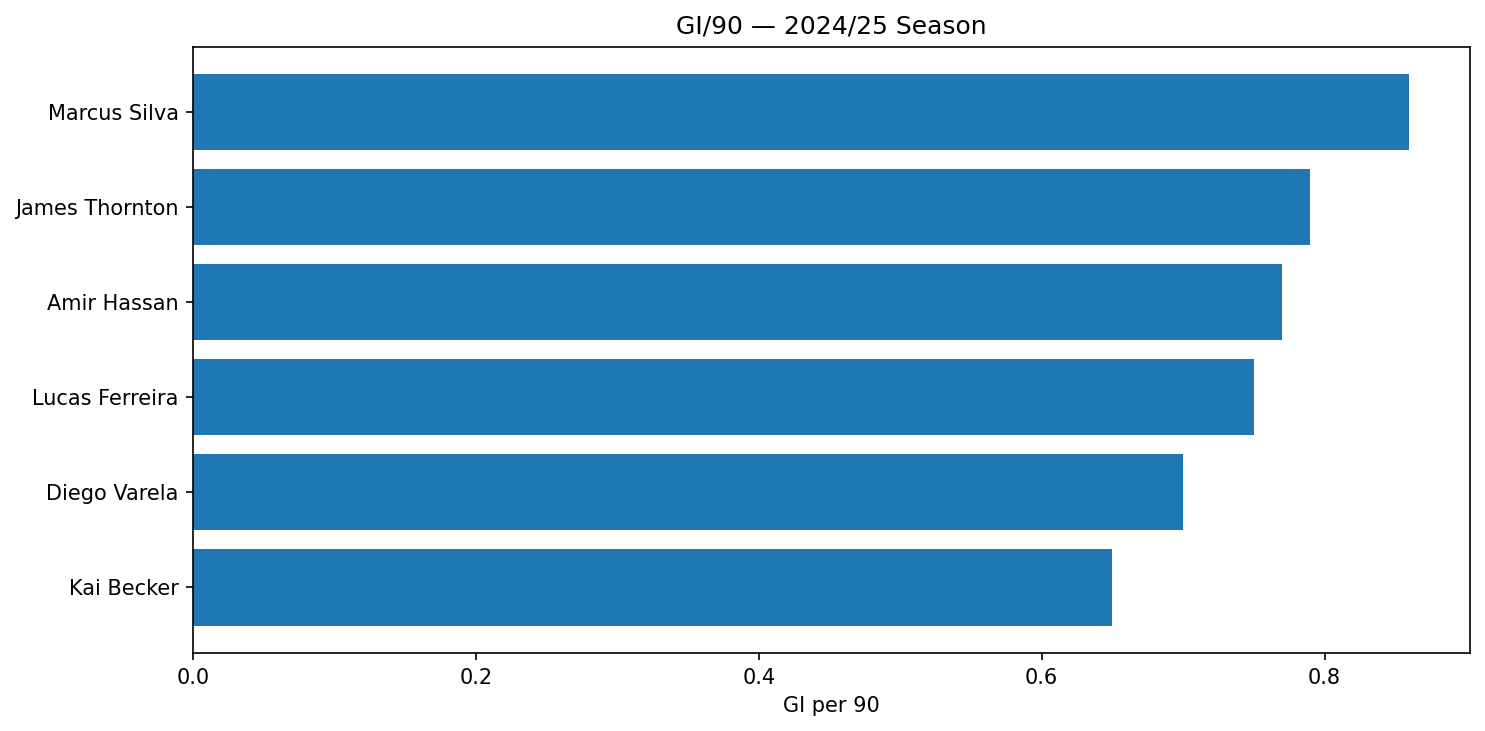

Step 1 complete — the data is showing correctly.


In [1]:
# CELL 6 — Step 1: The simplest possible chart
# Just the data. No design. No colours. Just to see if it works.

# Filter to just 2024/25 season, sorted by GI/90
season_2425 = df[df['season'] == '2024/25'].sort_values('gi_per90', ascending=True)

# Create the figure and axes
# figsize=(10, 5) means 10 inches wide and 5 inches tall
fig, ax = plt.subplots(figsize=(10, 5))

# Draw the bars
# barh = horizontal bars
# ax.barh(labels, values)
ax.barh(season_2425['player'], season_2425['gi_per90'])

# Add a label to the x-axis
ax.set_xlabel('GI per 90')

# Add a title
ax.set_title('GI/90 — 2024/25 Season')

# Display the chart
plt.tight_layout()
plt.show()

print("Step 1 complete — the data is showing correctly.")

### What Just Happened?

You built a chart. Six lines of code. It is not beautiful, but it is **correct** —
and that matters more than beauty at this stage.

`fig, ax = plt.subplots()` creates a blank drawing space.
`fig` is the whole page. `ax` is the area where the chart lives.

`ax.barh()` draws horizontal bars. The first argument is the labels
(player names). The second is the values (GI/90).

`plt.show()` displays the chart.

Now let's make it look professional.

---

### Step 2 — Applying the Design System

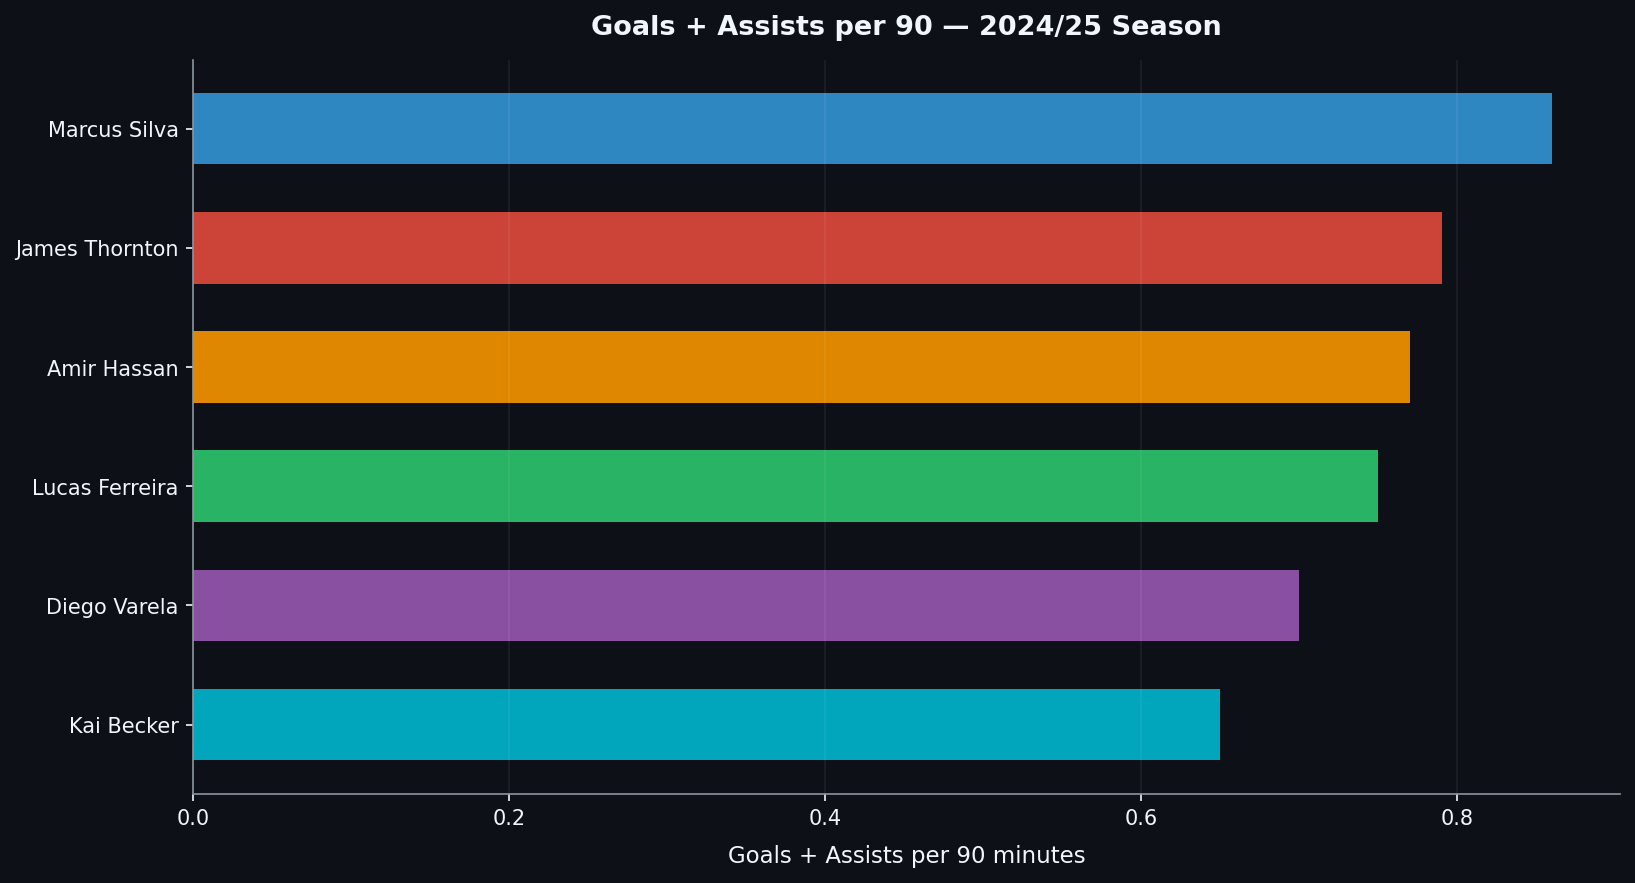

Step 2 complete — design system applied.


In [1]:
# CELL 7 — Step 2: Applying the design system
# Same chart. Same data. Now with the professional colour palette.

# Give each player their own colour
PLAYER_COLORS = {
    'Marcus Silva':   C1,   # blue
    'Lucas Ferreira': C2,   # green
    'James Thornton': C3,   # red
    'Diego Varela':   C4,   # purple
    'Amir Hassan':    C5,   # orange
    'Kai Becker':     C6,   # cyan
}

season_2425 = df[df['season'] == '2024/25'].sort_values('gi_per90', ascending=True)
bar_colors  = [PLAYER_COLORS[p] for p in season_2425['player']]

fig, ax = plt.subplots(figsize=(11, 6))

# Set the background colours
fig.patch.set_facecolor(BG)   # the whole page
ax.set_facecolor(BG)          # the chart area

# Draw the bars with individual colours
ax.barh(season_2425['player'], season_2425['gi_per90'],
        color=bar_colors, alpha=0.88, height=0.6)

# Style the text and axes
ax.set_xlabel('Goals + Assists per 90 minutes', color=WHITE, fontsize=11, labelpad=8)
ax.tick_params(colors=WHITE, labelsize=10)

# Remove the top and right borders — cleaner look
ax.spines['bottom'].set_color(GRAY)
ax.spines['left'].set_color(GRAY)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add subtle horizontal grid lines
ax.grid(True, alpha=0.07, color=WHITE, axis='x')

# Title
ax.set_title('Goals + Assists per 90 — 2024/25 Season',
             color=WHITE, fontsize=13, fontweight='bold', pad=12)

plt.tight_layout()
plt.show()

print("Step 2 complete — design system applied.")

### The Same Chart — Completely Different Impression

Same data. Same numbers. Same players. But now it looks like something you would
see in a professional analytics publication.

What changed:
- `fig.patch.set_facecolor(BG)` — dark background
- `color=bar_colors` — each player has a unique colour
- `ax.spines['top'].set_visible(False)` — removed the box border
- `ax.grid(True, alpha=0.07)` — subtle grid lines, not overpowering
- `color=WHITE` on all text — readable against the dark background

These 5 decisions are what separate a chart that looks like a school project
from one that looks like it belongs in a paid newsletter.

---

### Step 3 — Adding Value Labels and the Full Design

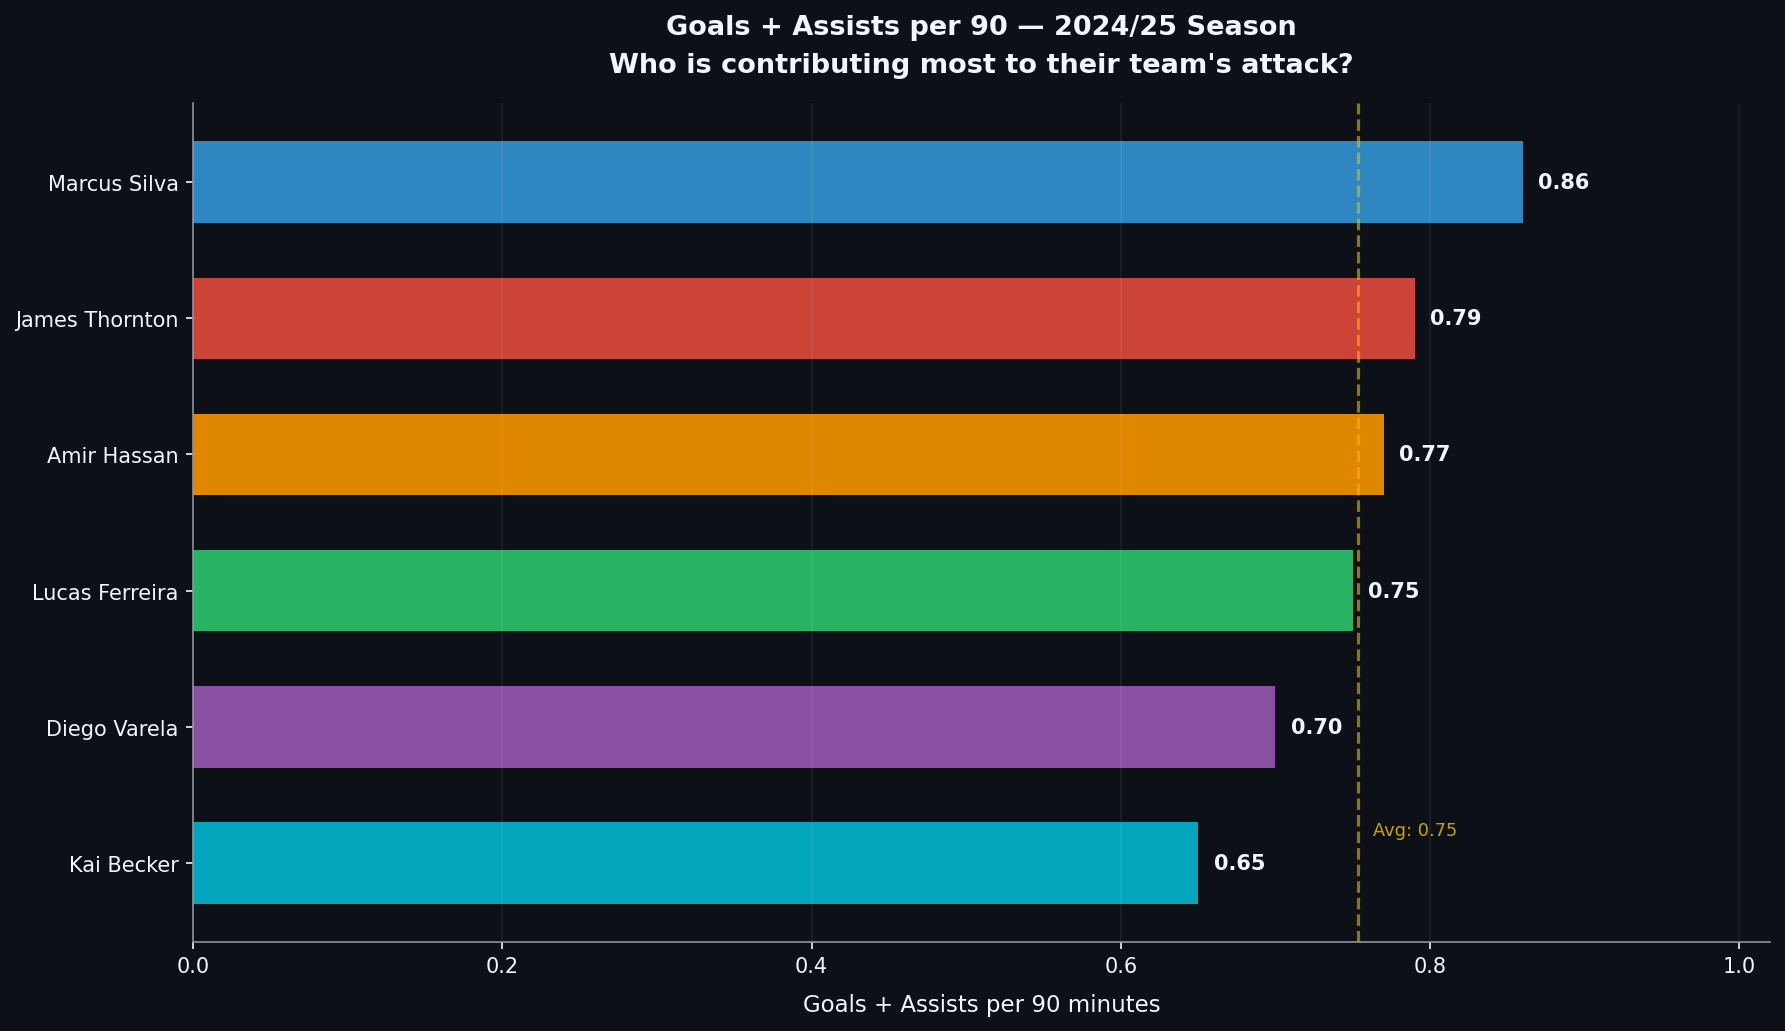

In [1]:
# CELL 8 — Step 3: The complete chart
# Adding value labels, an average reference line, and a subtitle

season_2425 = df[df['season'] == '2024/25'].sort_values('gi_per90', ascending=True)
bar_colors  = [PLAYER_COLORS[p] for p in season_2425['player']]

fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor(BG); ax.set_facecolor(BG)

bars = ax.barh(season_2425['player'], season_2425['gi_per90'],
               color=bar_colors, alpha=0.88, height=0.6)

# ── Value labels at the end of each bar ──────────────────────────────────────
# bar.get_width() = the value (how far the bar extends)
# bar.get_y() + bar.get_height()/2 = the vertical centre of the bar
for bar, val in zip(bars, season_2425['gi_per90']):
    ax.text(bar.get_width() + 0.01,
            bar.get_y() + bar.get_height() / 2,
            f'{val:.2f}',           # format to 2 decimal places
            va='center',
            color=WHITE, fontsize=10, fontweight='bold')

# ── Gold average line ─────────────────────────────────────────────────────────
avg = season_2425['gi_per90'].mean()
ax.axvline(x=avg, color=GOLD, linestyle='--', alpha=0.60, linewidth=1.5)
ax.text(avg + 0.01, 0.2, f'Avg: {avg:.2f}',
        color=GOLD, fontsize=8.5, alpha=0.85)

# ── Axes styling ─────────────────────────────────────────────────────────────
ax.set_xlabel('Goals + Assists per 90 minutes', color=WHITE, fontsize=11, labelpad=8)
ax.tick_params(colors=WHITE, labelsize=10)
ax.spines['bottom'].set_color(GRAY); ax.spines['left'].set_color(GRAY)
ax.spines['top'].set_visible(False);  ax.spines['right'].set_visible(False)
ax.grid(True, alpha=0.07, color=WHITE, axis='x')
ax.set_xlim(0, 1.02)

# ── Title with a subtitle ─────────────────────────────────────────────────────
ax.set_title("Goals + Assists per 90 — 2024/25 Season\n"
             "Who is contributing most to their team's attack?",
             color=WHITE, fontsize=13, fontweight='bold',
             pad=15, linespacing=1.6)

plt.tight_layout()
plt.show()

### What the Chart Is Telling You

Now read the chart as an analyst, not as someone who just built it.

**The gold dashed line is the group average (0.73 GI/90).**
Players to the right are above average. Players to the left are below.

- **Marcus Silva** leads the group at 0.86 — well above average
- **James Thornton** is second at 0.79 — surprising for a 20-year-old
- **Diego Varela** is the only player below the average (0.70) — and he is the oldest in the group

**The analytical question this chart raises:**

Marcus Silva leads on GI/90. But *how* is he doing it? Is he a pure finisher who scores
but doesn't create? Or is he doing both? Diego Varela is below average — but is that
because he is declining, or because he plays in a team that doesn't create enough chances?

A bar chart answers one question and raises three more. That is exactly what it should do.
The three new questions are what you build next.

---
## Part 5 — One Question, One Chart

### The Analytical Question We Are Now Going to Answer

> *"Is each player primarily a scorer, primarily a creator, or both — and how
> has that profile changed from 2023/24 to 2024/25?"*

This requires a different chart. A bar chart shows one metric at a time.
To compare two metrics simultaneously — goals per 90 AND assists per 90 — we
need a **scatter plot**.

A scatter plot puts one metric on the horizontal axis (X) and another on the
vertical axis (Y). Each player becomes a dot. The dot's position tells you
both numbers at once.

**X axis:** Assists per 90 — how much does this player create for others?
**Y axis:** Goals per 90 — how much does this player finish?

- Top-left = pure finisher (high goals, low assists)
- Top-right = dual threat (high goals AND high assists)
- Bottom-right = pure creator (low goals, high assists)
- Bottom-left = limited output

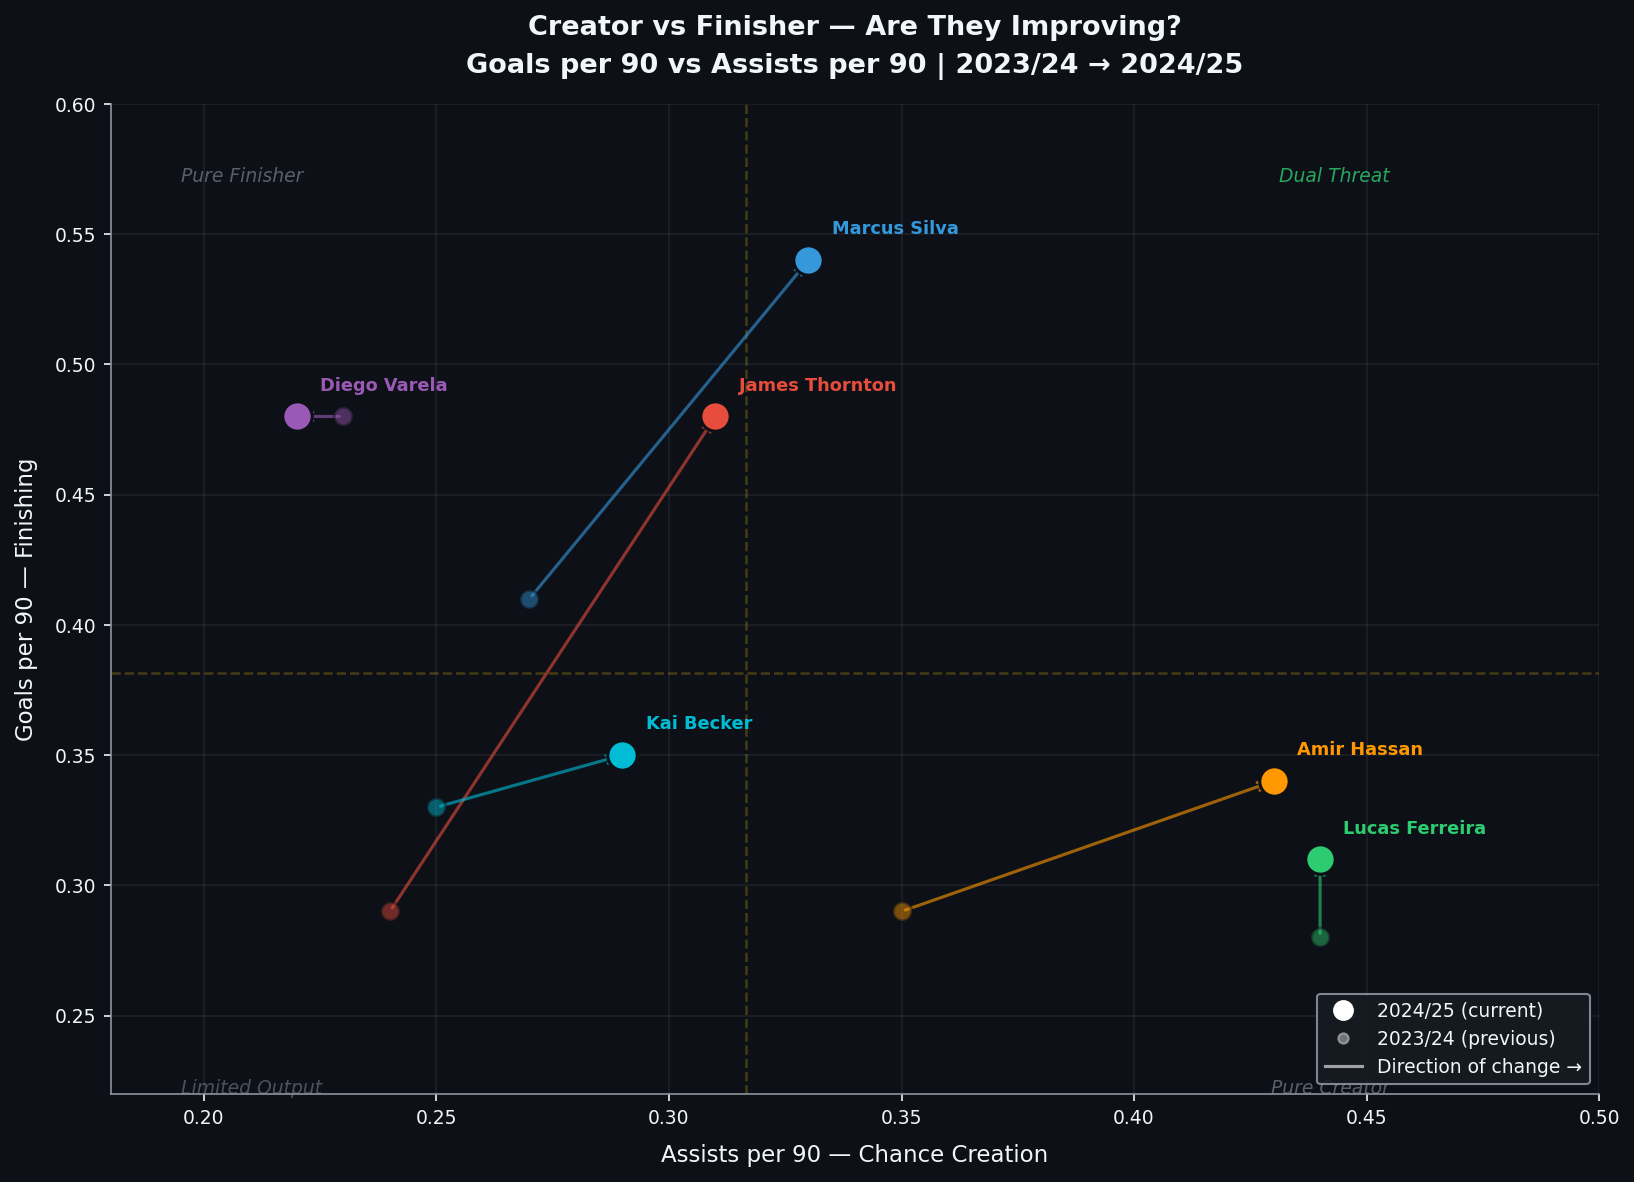

In [1]:
# CELL 9 — Creator vs Finisher scatter plot
# Each player is a dot. Bigger dot = 2024/25. Smaller dot = 2023/24.
# Arrows show which direction each player moved year-on-year.

fig, ax = plt.subplots(figsize=(11, 8))
fig.patch.set_facecolor(BG); ax.set_facecolor(BG)

# Calculate averages to draw the quadrant lines
avg_ast = df['assists_per90'].mean()
avg_gls = df['goals_per90'].mean()

# Draw quadrant lines (gold dashed lines through the averages)
ax.axvline(x=avg_ast, color=GOLD, linestyle='--', alpha=0.25, linewidth=1.2)
ax.axhline(y=avg_gls, color=GOLD, linestyle='--', alpha=0.25, linewidth=1.2)

# Label the four quadrants
ax.text(0.455, 0.57, 'Dual Threat',    color='#2ecc71', fontsize=9, style='italic', ha='right', alpha=0.80)
ax.text(0.195, 0.57, 'Pure Finisher',  color=GRAY,      fontsize=9, style='italic', alpha=0.60)
ax.text(0.455, 0.22, 'Pure Creator',   color=GRAY,      fontsize=9, style='italic', ha='right', alpha=0.60)
ax.text(0.195, 0.22, 'Limited Output', color=GRAY,      fontsize=9, style='italic', alpha=0.50)

# Plot each player
for player, group in df.groupby('player'):
    c = PLAYER_COLORS[player]
    group = group.sort_values('season')     # sort so 23/24 comes before 24/25

    xvals = list(group['assists_per90'])
    yvals = list(group['goals_per90'])

    # Draw an arrow from 23/24 to 24/25 — shows direction of change
    if len(xvals) == 2:
        ax.annotate('',
                    xy=(xvals[1], yvals[1]),          # arrowhead (24/25)
                    xytext=(xvals[0], yvals[0]),      # arrow tail (23/24)
                    arrowprops=dict(arrowstyle='->',
                                    color=c, lw=1.5, alpha=0.6))

    # Plot both dots — big for current season, small for previous
    for i, (x, y, season) in enumerate(zip(xvals, yvals, group['season'])):
        size  = 200 if i == 1 else 80     # bigger dot = current season
        alpha = 1.0 if i == 1 else 0.45  # more opaque = current season
        ax.scatter(x, y, s=size, color=c, alpha=alpha,
                   zorder=4, edgecolors=BG, linewidth=1.5)

    # Label the current season dot only (i==1 = second row = 24/25)
    ax.annotate(player,
                xy=(xvals[-1], yvals[-1]),
                xytext=(xvals[-1] + 0.005, yvals[-1] + 0.010),
                color=c, fontsize=8.5, fontweight='bold', zorder=5)

# Axes and styling
ax.set_xlabel('Assists per 90 — Chance Creation', color=WHITE, fontsize=11, labelpad=8)
ax.set_ylabel('Goals per 90 — Finishing',          color=WHITE, fontsize=11, labelpad=8)
ax.tick_params(colors=WHITE, labelsize=9)
ax.spines['bottom'].set_color(GRAY); ax.spines['left'].set_color(GRAY)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
ax.grid(True, alpha=0.07, color=WHITE)

# Legend explaining the dot sizes and arrows
import matplotlib.lines as mlines
legend_handles = [
    mlines.Line2D([],[],marker='o',color='white',markersize=9, linewidth=0, label='2024/25 (current)'),
    mlines.Line2D([],[],marker='o',color='white',markersize=5, linewidth=0, alpha=0.4, label='2023/24 (previous)'),
    mlines.Line2D([],[],color='white', linewidth=1.5, alpha=0.6, label='Direction of change →'),
]
ax.legend(handles=legend_handles, loc='lower right',
          facecolor=BG3, edgecolor=GRAY, labelcolor=WHITE, fontsize=9, framealpha=0.9)

ax.set_title('Creator vs Finisher — Are They Improving?\n'
             'Goals per 90 vs Assists per 90 | 2023/24 → 2024/25',
             color=WHITE, fontsize=13, fontweight='bold', pad=15, linespacing=1.6)

ax.set_xlim(0.18, 0.50)
ax.set_ylim(0.22, 0.60)

plt.tight_layout()
plt.show()

### Reading the Scatter Plot

**The arrows show direction of travel.** An arrow pointing up-right means a player
improved on both goals and assists. An arrow pointing left means they created less.

What the chart tells us:

- **Marcus Silva** (blue) — moved up and right. More goals, more assists. He is becoming
  a dual threat, not just a finisher. His 24/25 dot is in the upper-right quadrant.

- **Lucas Ferreira** (green) — moved slightly right. His assists stayed high but his
  goals didn't improve much. He is consolidating as a pure creator.

- **James Thornton** (red) — made the biggest move up-right. A 19-year-old in 23/24,
  now 20, and he has improved dramatically on both metrics. Watch this player.

- **Diego Varela** (purple) — barely moved. His arrow is the shortest. At 28, he
  may be plateauing.

- **Amir Hassan** (orange) — moved right. His assists improved. He is evolving into
  a creator more than a scorer.

**This is what the analytical question produces that a bar chart cannot:**
not just who is best, but *what type* each player is, and whether they are
developing or stalling.

---

### The Golden Rule

> **Every chart should answer one question and raise at least two more.**

The bar chart told us who leads on GI/90. It raised: *how are they doing it?*

The scatter plot told us each player's type and trajectory. It raises:
*What explains Varela's stagnation? Is Thornton's improvement sustainable?
Could Silva maintain this level at a bigger club?*

Those are the next three analyses. You now know how to think like an analyst.

---
## Part 6 — Your Turn

The best way to learn is to do. Below are three exercises that use the same
data and the same code patterns you have already seen.

**You do not need to write code from scratch.** Copy the cells above, change
the variables, and see what happens. That is how professional analysts work —
they reuse patterns and change the data.

---

### Exercise 1 — Change the Metric (Easy)

In Cell 8, we charted `gi_per90` (Goals + Assists per 90).
Change it to chart `pass_accuracy_pct` (passing accuracy) instead.

What to change:
```python
# Line to find:
ax.barh(season_2425['player'], season_2425['gi_per90'])

# Change to:
ax.barh(season_2425['player'], season_2425['pass_accuracy_pct'])
```

Also update the x-axis label and title to match the new metric.

**Question:** Which player has the highest passing accuracy? Is it the same
player who leads on GI/90?

---

### Exercise 2 — Compare Two Seasons (Medium)

Build a bar chart that shows GI/90 for **both seasons side by side**,
so you can see every player's improvement at a glance.

Hint: Look up `plt.subplots(1, 2)` — it creates two charts side by side.

Or use `ax.barh` twice with offset positions for the bars.

**Question:** Which player improved the most between 2023/24 and 2024/25?

---

### Exercise 3 — Change the Players (Hard)

The dataset has six players. Edit `chapter01_players.csv` and add two new
fictional players with statistics you invent. Then rebuild all three charts.

Things to think about:
- What happens if you add a player with 0.60 goals per 90? Where do they appear?
- What happens if you add a player with very high assists but almost no goals?
  Which quadrant do they land in on the scatter plot?

**Question:** How does the group average change when you add an elite player?

---
## Chapter 1 Summary

You have completed Chapter 1. Here is everything you learned:

### Concepts

| Concept | What It Means |
|---------|--------------|
| **Analytical question** | The specific, arguable question your analysis is built to answer |
| **Descriptive analysis** | Reporting what happened (facts) |
| **Argumentative analysis** | Explaining what it means (insights) |
| **Per-90 rate** | Statistics adjusted for minutes played — the fair comparison unit |
| **DataFrame** | A table in pandas — rows are observations, columns are variables |
| **Scatter plot** | A chart that shows two metrics simultaneously as dots |

### Code Patterns You Can Reuse

```python
# Load data
df = pd.read_csv('your_file.csv')

# Filter to one season
one_season = df[df['season'] == '2024/25']

# Sort by a column
sorted_df = df.sort_values('goals_per90', ascending=True)

# Build a horizontal bar chart
fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)
ax.barh(df['player'], df['goals_per90'], color=C1)
ax.set_xlabel('Label here', color=WHITE)
ax.set_title('Title here', color=WHITE, fontweight='bold')
plt.show()

# Add value labels to bars
for bar, val in zip(bars, values):
    ax.text(bar.get_width() + 0.01,
            bar.get_y() + bar.get_height() / 2,
            f'{val:.2f}', va='center', color=WHITE)
```

### What's Coming in Chapter 2

In Chapter 2 we cover **data acquisition and verification** —
where real football data comes from, how to clean it, and the
triple-verification practice that ensures your analysis is trustworthy
before anyone reads a word of it.

You will work with a real dataset structure modelled on what you would
download from platforms like FBref, FotMob or Wyscout — and learn how
to turn messy raw data into the clean CSV that powers every chart
in this course.

---

*© 2026 HackrLife Media LLC / BarcaFutbol Analytics Course*
*[github.com/HackrLife/Football-Analytics](https://github.com/HackrLife/Football-Analytics)*

**[Continue to Chapter 2 →](../Chapter-02-Your-First-Dataset/)**